# Exercise 1: Descriptive statistics with Palmer Penguins

This exercise uses the Palmer Penguins dataset (`seaborn.load_dataset('penguins')`) and ties directly to the **M3-1: Statistical Analysis** learning outcomes. Work through the sections in order. Where you are asked for prose, use your own words in a short paragraph unless a bullet list is requested.

Dataset reference: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/).

In [2]:
%pip install numpy
%pip install pandas
%pip install seaborn



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Meet the Palmer penguins

![](../assets/lter_penguins.png)

### Bill dimensions

The culmen is the upper ridge of a bird’s bill. In the simplified `penguins` data, culmen length and depth are renamed as variables `bill_length_mm` and `bill_depth_mm` to be more intuitive.

For this penguin data, the culmen (bill) length and depth are measured as shown below (thanks Kristen Gorman for clarifying!):

![](../assets/culmen_depth.png)

## A. Concepts: what statistics is and how we use data

**1.** For this dataset, what is a reasonable **population** you might want to learn about? What is the **sample** you actually have in `df`? (One or two sentences each.)

**2.** List every column in `df`. For each, label it **numerical** or **categorical** (if a column could be debated, say why).

**3.** Give **two new examples** of variables that are clearly numerical and **two** that are clearly categorical *not* in this table (any domain you like).


1:
 Population: A reasonable population is the broader group of penguins we want to learn about, such as penguins from the Palmer Archipelago represented by this dataset.

Sample: The sample is the set of penguins actually recorded in df, including their species, island, bill measurements, flipper length, body mass, and sex.

2:
species : categorical
island : categorical
bill_length_mm : numerical
bill_depth_mm : numerical
flipper_length_mm : numerical
body_mass_g : numerical
sex : categorical

3:
Numerical variables:
student exam score
car speed

Categorical variables:
blood type
phone brand

## B. Calculations on the sample: proportion, mean, variance

Use the cleaned numeric columns only where needed (drop rows with missing body mass or bill length, or use `.dropna(subset=[...])` as you prefer). Show your code and round printed numbers sensibly.

**1.** For the variable `body_mass_g`:

- Compute the **proportion** of penguins with body mass **greater than** the overall median body mass (among non-missing values).
- Compute the **mean** and **variance** of `body_mass_g` (same subset).

In [5]:
body = df.dropna(subset=["body_mass_g"])["body_mass_g"]

median_body = body.median()
prop_gt_median = (body > median_body).mean()
mean_body = body.mean()
var_body = body.var()

print("Median body mass:", round(median_body, 2))
print("Proportion > median:", round(prop_gt_median, 4))
print("Mean:", round(mean_body, 2))
print("Variance:", round(var_body, 2))

Median body mass: 4050.0
Proportion > median: 0.4854
Mean: 4201.75
Variance: 643131.08


**2.** For `body_mass_g`, identify at least **two** distributional summary measures that describe **center** and **spread** (name them and compute them). Optionally add a third that describes **shape** (e.g. skewness), if you know how to compute it.

In [6]:
std_body = body.std()
q1 = body.quantile(0.25)
q3 = body.quantile(0.75)
iqr = q3 - q1
skew_body = body.skew()

print("Mean:", round(mean_body, 2))
print("Median:", round(median_body, 2))
print("Standard deviation:", round(std_body, 2))
print("IQR:", round(iqr, 2))
print("Skewness:", round(skew_body, 3))

Mean: 4201.75
Median: 4050.0
Standard deviation: 801.95
IQR: 1200.0
Skewness: 0.47


## C. Shape of distributions: vocabulary and examples

**1.** Briefly define each shape in your own words: **normal (Gaussian)**, **uniform**, **skewed**, **exponential**.

**2.** Give **two real-world examples** of quantities that are *often modeled as* roughly normally distributed (they need not be perfect). (you can search the internet)

**3.** Give **one example** of data that is typically **not** normal—e.g. **exponential-like** or strongly skewed—and say why. (you can search the internet)

1:
Normal : It has a bell shape, and most values are close to the middle, with both sides looking similar.
Uniform : The values are spread out evenly.
Skewed : It is not balanced, and one side is longer than the other.
Exponential : It has many small values and only a few large values.

2:
Human height
Exam scores

3:
Waiting time, such as the time until the next customer arrives
This is because most waiting times are short, and only a few are long.

## D. Percentiles and the empirical rule (normal distribution)

Work on `body_mass_g` (non-missing) or `bill_length_mm`—pick one and stick to it for this section.

**1.** In plain language, explain what the **75th percentile** of body mass means for a penguin in this sample.
**2.** Compute the **25th, 50th, and 75th percentiles** for your chosen variable.

In [7]:
body = df.dropna(subset=["body_mass_g"])["body_mass_g"]

percentiles = body.quantile([0.25, 0.50, 0.75])
print(percentiles)

0.25    3550.0
0.50    4050.0
0.75    4750.0
Name: body_mass_g, dtype: float64


Assume for **discussion** that flipper length (or another chosen numeric column) were **exactly** normal with the mean and standard deviation you observe in the sample.

**3.** For a normal distribution, explain what share of values fall within **1**, **2**, and **3 standard deviations** of the mean (the empirical rule). Then **compute** the interval $\mu \pm 1\sigma$, $\mu \pm 2\sigma$, and $\mu \pm 3\sigma$ using your sample $\mu$ and $\sigma$ for that variable.

In [8]:
fl = df.dropna(subset=["flipper_length_mm"])["flipper_length_mm"]

mu = fl.mean()
sigma = fl.std()

print("mu:", round(mu, 2))
print("sigma:", round(sigma, 2))
print("mu ± 1σ:", (round(mu - sigma, 2), round(mu + sigma, 2)))
print("mu ± 2σ:", (round(mu - 2*sigma, 2), round(mu + 2*sigma, 2)))
print("mu ± 3σ:", (round(mu - 3*sigma, 2), round(mu + 3*sigma, 2)))

mu: 200.92
sigma: 14.06
mu ± 1σ: (np.float64(186.85), np.float64(214.98))
mu ± 2σ: (np.float64(172.79), np.float64(229.04))
mu ± 3σ: (np.float64(158.73), np.float64(243.1))


## E. Box plot: read the graphic

**1.** (SOLVED) Draw a **box plot** of `body_mass_g`, split by `species`.

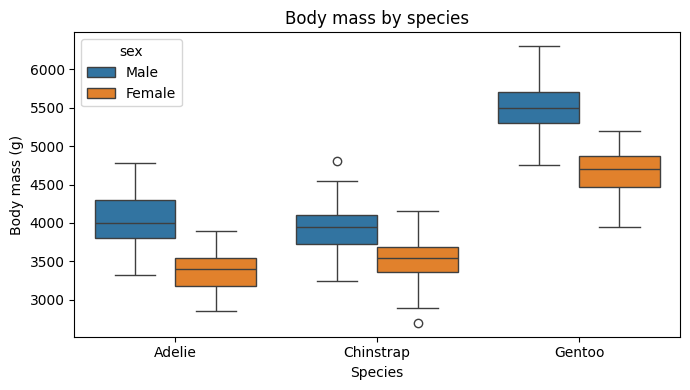

In [9]:
#| label: boxplot-body-mass-by-species
#| fig-cap: "Body mass (g) by penguin species"
import matplotlib.pyplot as plt
import seaborn as sns

df_box = sns.load_dataset("penguins").dropna(subset=["body_mass_g", "species"])

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_box, x="species", y="body_mass_g", hue='sex', ax=ax)
ax.set_title("Body mass by species")
ax.set_xlabel("Species")
ax.set_ylabel("Body mass (g)")
plt.tight_layout()

**2.** On your plot, **label or describe** what each part represents: median, quartiles, whiskers, and points outside the whiskers (if any). What does the box width tell you?

The line inside the box is the median.
The bottom and top of the box are the first and third quartiles.
The whiskers extend to non-outlier values near the rest of the data.
Points beyond the whiskers are possible outliers.
In a standard box plot, the box width itself does not represent more observations; the important part is the vertical spread.


**3.** Write **two** sentences about the sample using words like **“most”** and **“few”** (e.g. which species tend to be heavier). Base this only on what you see in the plot.

1: Most Gentoo penguins appear heavier than most Adelie and Chinstrap penguins.
2: Few observations appear far from the rest, although some groups may show possible outliers.

**4.** Write **one** quantitative claim about the data (e.g. “the median body mass of Chinstrap is above 3500 g”). Then **verify** it with code (`groupby`, `median`, etc.) and state whether your claim was **true or false**.

The median body mass of Gentoo penguins is above 4500 g. I verified this by grouping the data by species and calculating the median of body_mass_g. The result shows that the median body mass for Gentoo penguins is 5000 g, so the claim is true.


Use the cell below as a starting point: it prints **medians by species** and shows one example check (Chinstrap median vs 3500 g). Adapt the last lines to match *your* claim.


In [10]:
#| label: verify-median-example
import seaborn as sns

df_v = sns.load_dataset("penguins").dropna(subset=["body_mass_g", "species"])

medians = df_v.groupby("species", observed=True)["body_mass_g"].median()
print("Median body mass (g) by species:")
print(medians)

# Example verification — replace with checks that match your own claim
chin_median = medians.get("Chinstrap")
print("\nExample claim: Chinstrap median > 3500 g")
print("  Chinstrap median:", chin_median)
print("  Claim is true:", chin_median > 3500)

Median body mass (g) by species:
species
Adelie       3700.0
Chinstrap    3700.0
Gentoo       5000.0
Name: body_mass_g, dtype: float64

Example claim: Chinstrap median > 3500 g
  Chinstrap median: 3700.0
  Claim is true: True


## F. Outliers

**1.** Name **two** methods for identifying or **removing outliers** on a numeric column. For each, give a **one-sentence** explanation of the rule. Then show **one** method applied in code to flag outliers in `bill_length_mm` (do not delete them from the full dataset the count or indices is enough).

In [11]:
bill = df.dropna(subset=["bill_length_mm"]).copy()

Q1 = bill["bill_length_mm"].quantile(0.25)
Q3 = bill["bill_length_mm"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = bill[
    (bill["bill_length_mm"] < lower) |
    (bill["bill_length_mm"] > upper)
]

print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of outliers:", len(outliers))
print("Indices:", outliers.index.tolist())

Lower bound: 25.312500000000004
Upper bound: 62.412499999999994
Number of outliers: 0
Indices: []
